# Loading data

Customer Churn analysis

In [8]:
import pandas as pd
from sqlalchemy import create_engine

# Database Connection Configuration
USER, PASSWORD, HOST, DB = 'bt4301', 'password', 'localhost', 'customer_churn'
engine = create_engine(f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DB}')

Load Data

In [ ]:
query = """
SELECT
    f.customer_id,
    f.churn,
    f.monthlycharges,
    f.totalcharges,
    f.avg_charge_per_month,
    c.age,
    c.gender,
    c.annual_income,
    c.education,
    c.marital_status,
    c.dependents,
    c.senior_citizen,
    c.household_size,
    c.tenure_segment,
    a.tenure,
    a.contract,
    a.payment_method,
    a.paperless_billing,
    s.num_services,
    s.has_phone_service,
    s.has_internet_service,
    s.has_online_security,
    s.has_online_backup,
    s.has_device_protection,
    s.has_tech_support,
    s.has_streaming_tv,
    s.has_streaming_movies,
    b.customer_satisfaction,
    b.num_complaints,
    b.num_service_calls,
    b.late_payments,
    b.avg_monthly_gb,
    b.days_since_last_interaction,
    b.credit_score,
    b.high_risk_flag
FROM fact_customer_churn f
LEFT JOIN dim_customer  c ON f.customer_id = c.customer_id
LEFT JOIN dim_account   a ON f.customer_id = a.customer_id
LEFT JOIN dim_service   s ON f.customer_id = s.customer_id
LEFT JOIN dim_behavior  b ON f.customer_id = b.customer_id
"""

df = pd.read_sql(query, engine)
print(f"Columns available: {df.columns}")
print(f"Number of rows: {len(df)}")

df.head()

In [12]:
query = """
SELECT * FROM train_churn_model
"""

df_train = pd.read_sql(query, engine)
print(f"Columns available: {df_train.columns}")
print(f"Number of rows: {len(df_train)}")

df_train.head()

Columns available: Index(['customer_id', 'churn', 'annual_income', 'contract',
       'has_phone_service', 'has_internet_service', 'has_tech_support',
       'has_streaming_tv', 'has_streaming_movies', 'customer_satisfaction',
       'num_complaints', 'num_service_calls', 'late_payments',
       'high_risk_flag', 'age_group', 'tenure_segment', 'is_auto_pay'],
      dtype='object')
Number of rows: 1000000


,customer_id,churn,annual_income,contract,has_phone_service,has_internet_service,has_tech_support,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,high_risk_flag,age_group,tenure_segment,is_auto_pay
0,CUST0000000047,0,30347.14,one_year,1,1,1,1,0,8.0,0.0,0,0,0,40-49,Loyal,1
1,CUST0000000091,0,48954.60,one_year,0,1,1,0,0,7.0,0.0,0,0,1,40-49,Loyal,1
2,CUST0000000140,0,71159.08,two_year,1,0,0,0,1,6.0,1.0,2,0,0,50-59,Stable,1
3,CUST0000000202,0,20000.00,one_year,1,1,1,1,0,5.0,0.0,1,1,0,30-39,Loyal,1
4,CUST0000000214,0,34528.27,two_year,1,1,1,1,0,8.0,0.0,2,1,0,40-49,Infant,1


In [11]:
query = """SELECT * FROM dim_customer"""

df_cust = pd.read_sql(query, engine)
print(f"Columns available: {df_cust.columns}")
print(f"Number of rows: {len(df_cust)}")

df_cust.head()

Columns available: Index(['customer_id', 'signup_date', 'age', 'gender', 'annual_income',
       'education', 'marital_status', 'dependents', 'senior_citizen'],
      dtype='object')
Number of rows: 1000000


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,senior_citizen
0,CUST0000000001,2022-12-12 12:53:58,43,Female,55085.25,college,married,1,0
1,CUST0000000002,2022-01-13 12:53:58,18,Male,60786.11,master,married,1,0
2,CUST0000000003,2023-09-04 12:53:58,38,Female,73184.32,high_school,widowed,0,0
3,CUST0000000004,2022-06-27 12:53:58,44,Male,40923.78,high_school,married,1,0
4,CUST0000000005,2022-12-08 12:53:58,45,Female,36400.94,bachelor,single,0,0


# Variables vs Churn

## Churn & unchurned by annual_income

In [5]:
df['annual_income'].describe()

count    1000000.000000
mean       58493.746060
std        36615.325624
min        20000.000000
25%        33185.465000
50%        48987.690000
75%        72420.440000
max       250000.000000
Name: annual_income, dtype: float64

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# create age_group column
df['income_group'] = pd.cut(df['annual_income'], 
                         bins=[0, 35000, 55000, 85000, 130000, 250000], 
                         labels=['Low', 'Middle-lower', 'Middle-upper', 'Upper', 'Affluent'])

sns.set_theme(style="whitegrid")

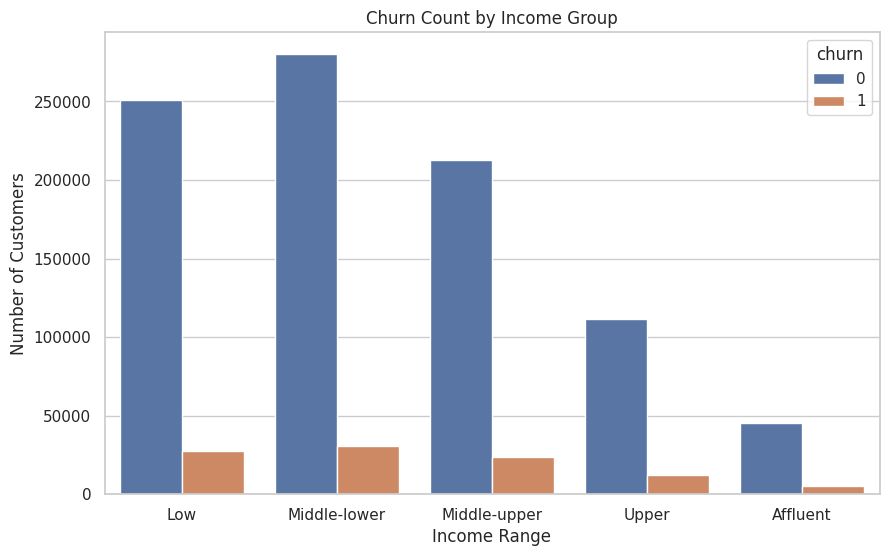

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='income_group', hue='churn')
plt.title('Churn Count by Income Group')
plt.xlabel('Income Range')
plt.ylabel('Number of Customers')
plt.show()

In [10]:
income_churn_pct = df.groupby('income_group')['churn'].value_counts(normalize=True).unstack() * 100
income_churn_pct

/tmp/ipykernel_63575/210534570.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_churn_pct = df.groupby('income_group')['churn'].value_counts(normalize=True).unstack() * 100


churn,0,1
income_group,,
Low,90.063822,9.936178
Middle-lower,90.124478,9.875522
Middle-upper,90.055618,9.944382
Upper,90.099908,9.900092
Affluent,89.907894,10.092106


Observation: The rate of churn remains generally similar across the different income_groups.  

Inference: This suggests that Income group might not be the most significant factor when predicting customer churn.

## Churn & unchurned by age 


In [36]:
# Create age groups
import seaborn as sns
import matplotlib.pyplot as plt

# create age_group column
df['age_group'] = pd.cut(df['age'], 
                         bins=[18, 30, 40, 50, 60, 70, 100], 
                         labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+'])

sns.set_theme(style="whitegrid")

In [37]:
df['age_group'].unique()

['40-49', '50-59', '30-39', '60-69', '18-29', NaN, '70+']
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

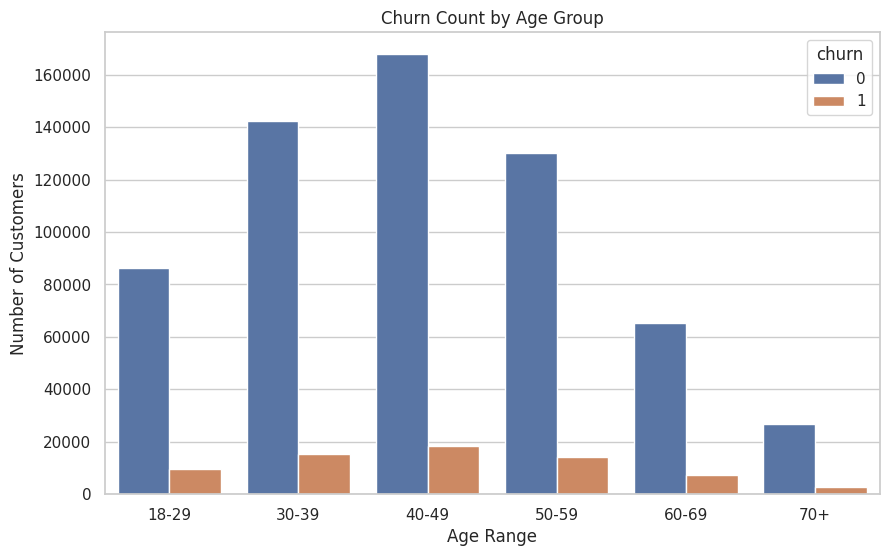

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='churn')
plt.title('Churn Count by Age Group')
plt.xlabel('Age Range')
plt.ylabel('Number of Customers')
plt.show()

Observation: The 40–49 age group has the highest raw count of churners, followed by the 30–39 and 50–59 groups. The youngest (18–29) and oldest (70+) groups have the lowest total churn volume.

Inference: This suggests that Age has a non-linear relationship with churn. Using raw age might be less effective than using age bins (like the ones in your chart) to capture these lifecycle-specific risks.

## Contract type vs churn


In [7]:
# Different contract types
df['contract'].unique()

array(['one_year', 'two_year', 'month_to_month'], dtype=object)

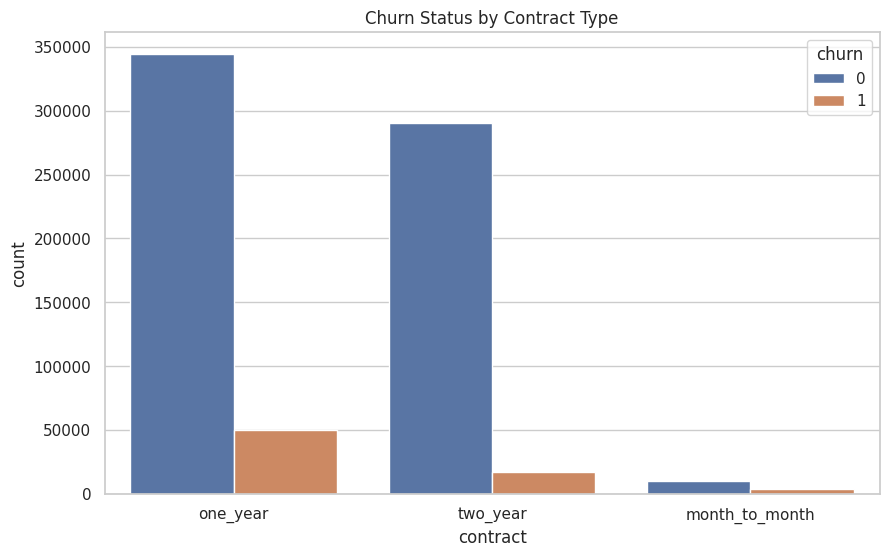

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='contract', hue='churn')
plt.title('Churn Status by Contract Type')
plt.show()

In [13]:
contract_churn_pct = df.groupby('contract')['churn'].value_counts(normalize=True).unstack() * 100
contract_churn_pct

churn,0,1
contract,,
month_to_month,73.597591,26.402409
one_year,87.284310,12.715690
two_year,94.341168,5.658832


Observation: While "One-Year" and "Two-Year" contracts have the highest total counts, the Ratio of Churn is actually highest in the "Month-to-Month" or "One-Year" categories.

Inference: Contract type is likely your strongest categorical feature. In your pipeline, ensure you use One-Hot Encoding for this variable, as the difference in churn behavior between a "Two-Year" and "Month-to-Month" customer is massive.

## Monthly charge vs churn


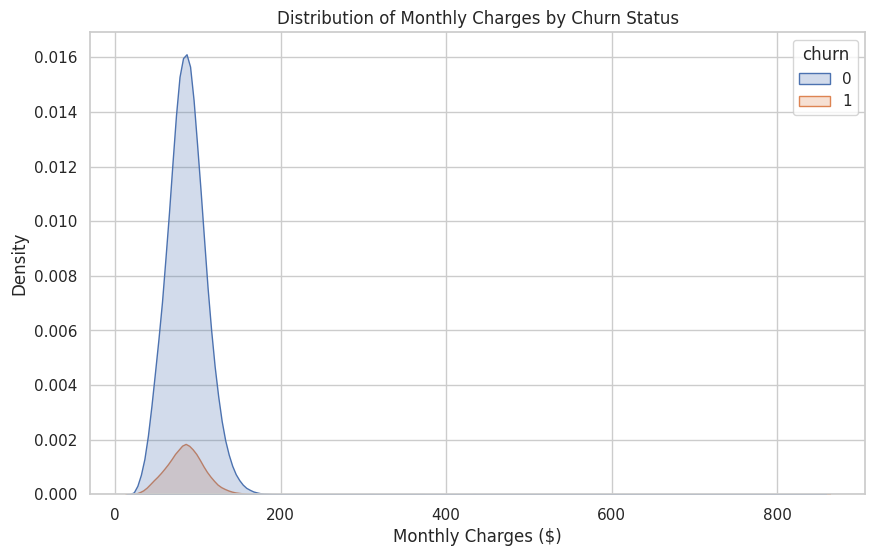

In [9]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='monthlycharges', hue='churn', fill=True)
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges ($)')
plt.show()

Observation: The density plot of the blue and orange curves almost perfectly overlap. Churners and Non-Churners have nearly identical distributions of monthly spending, peaking around $80–$100.

Inference: Monthly Charges may be a weak predictor on its own. It tells us that customers aren't necessarily leaving because their bill is "too high" compared to others; they are leaving for other reasons (likely service quality or tenure).

## Tenure distribution by churn

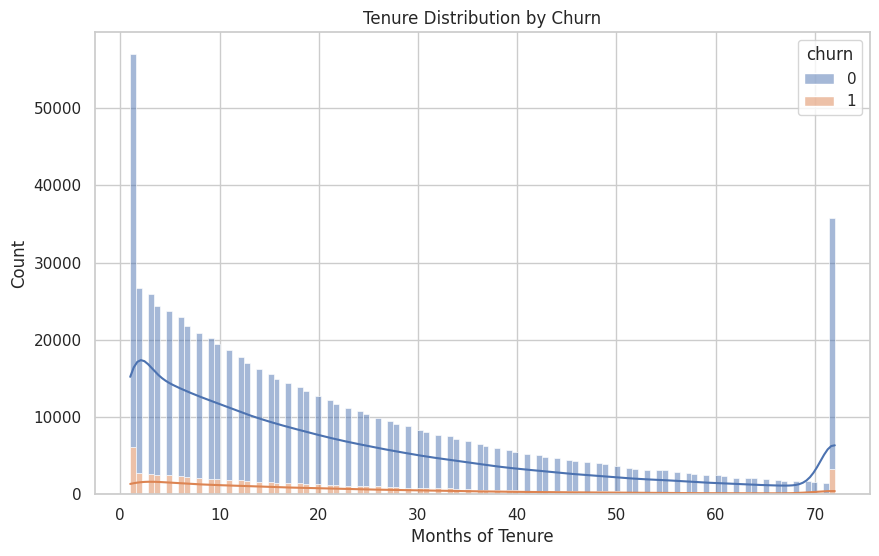

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='churn', multiple="stack", kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Months of Tenure')
plt.show()

Observation: Churn is heavily skewed toward the first 1–5 months. Once a customer survives the 24-month mark, their likelihood of churning drops to nearly zero.

MLOps: You should create a "New Customer" flag or a categorical feature for tenure (e.g., < 6 months, 6-24 months, > 24 months). The model needs to focus on the high-volatility early months.

The "Leakage" Warning: When you move to the modeling phase, be careful with "Tenure" and "Contract Type" together. If a "Two-Year" contract forces a customer to stay for 24 months, the model might "cheat" by seeing high tenure and low churn as a rule, rather than a prediction.

# Evaluating Feature Relevance & Correlation

Customer dimension

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.feature_selection import mutual_info_classif

continuous_features = ['dependents']
categorical_features = ['tenure_segment', 'age_group', 'income_group', 'education', 'marital_status', 'household_size']

results = []

for col in continuous_features:
    # Ensure no NaNs for the calculation
    valid_df = df[[col, 'churn']].dropna()
    corr, p_val = pointbiserialr(valid_df[col], valid_df['churn'])
    results.append({'Feature': col, 'Type': 'Numeric', 'Metric_Value': corr, 'P_Value': p_val})

# 3. Evaluate Categorical Features (Chi-Square Test)
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['churn'])
    chi2, p_val, dof, ex = chi2_contingency(contingency_table)
    # We use Cramér's V to get a 0-1 scale of association strength
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    results.append({'Feature': col, 'Type': 'Categorical', 'Metric_Value': cramers_v, 'P_Value': p_val})

# 4. Global Ranking: Mutual Information, how much knowing this feature reduces uncertainty about churn
# We take a 10% sample (100k) for MI to keep it fast while staying accurate
df_sample = df.sample(100000)
X = pd.get_dummies(df_sample[continuous_features + categorical_features + binary_features], drop_first=True)
y = df_sample['churn']

mi_scores = mutual_info_classif(X, y, discrete_features='auto')
mi_results = pd.DataFrame({'Feature_Encoded': X.columns, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

# Output Summary
eval_df = pd.DataFrame(results).sort_values(by='Metric_Value', ascending=False)
print("--- Statistical Association ---")
print(eval_df)
print("\n--- Mutual Information (Predictive Power) ---")
print(mi_results.head(10))

--- Statistical Association ---
          Feature         Type  Metric_Value   P_Value
2       age_group  Categorical      0.003237  0.074062
1  tenure_segment  Categorical      0.002582  0.083398
5  marital_status  Categorical      0.002220  0.177093
6  household_size  Categorical      0.001628  0.753540
3    income_group  Categorical      0.001628  0.618022
4       education  Categorical      0.001578  0.646689
0      dependents      Numeric     -0.000145  0.884443

--- Mutual Information (Predictive Power) ---
              Feature_Encoded  MI_Score
3        tenure_segment_Loyal  0.015862
19     marital_status_married  0.009980
4       tenure_segment_Stable  0.004952
1              household_size  0.004894
11  income_group_Middle-lower  0.004772
20      marital_status_single  0.004468
0                  dependents  0.003976
16      education_high_school  0.003638
15          education_college  0.003555
12  income_group_Middle-upper  0.003060


Account dimension

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.feature_selection import mutual_info_classif

# 1. Setup the feature lists based on your image
continuous_features = ['tenure']
categorical_features = ['contract', 'payment_method', 'paperless_billing']

results = []

# 2. Evaluate Continuous & Binary Features (Point-Biserial Correlation)
for col in continuous_features:
    # Ensure no NaNs for the calculation
    valid_df = df[[col, 'churn']].dropna()
    corr, p_val = pointbiserialr(valid_df[col], valid_df['churn'])
    results.append({'Feature': col, 'Type': 'Numeric', 'Metric_Value': corr, 'P_Value': p_val})

# 3. Evaluate Categorical Features (Chi-Square Test)
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['churn'])
    chi2, p_val, dof, ex = chi2_contingency(contingency_table)
    # We use Cramér's V to get a 0-1 scale of association strength
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    results.append({'Feature': col, 'Type': 'Categorical', 'Metric_Value': cramers_v, 'P_Value': p_val})

# 4. Global Ranking: Mutual Information
# We take a 10% sample (100k) for MI to keep it fast while staying accurate
df_sample = df.sample(100000)
X = pd.get_dummies(df_sample[continuous_features + categorical_features + binary_features], drop_first=True)
y = df_sample['churn']

mi_scores = mutual_info_classif(X, y, discrete_features='auto')
mi_results = pd.DataFrame({'Feature_Encoded': X.columns, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

# Output Summary
eval_df = pd.DataFrame(results).sort_values(by='Metric_Value', ascending=False)
print("--- Statistical Association ---")
print(eval_df)
print("\n--- Mutual Information (Predictive Power) ---")
print(mi_results.head(10))

--- Statistical Association ---
             Feature         Type  Metric_Value       P_Value
1           contract  Categorical      0.139670  0.000000e+00
3  paperless_billing  Categorical      0.001312  1.896012e-01
2     payment_method  Categorical      0.000836  8.733100e-01
0             tenure      Numeric     -0.012709  5.257930e-37

--- Mutual Information (Predictive Power) ---
                   Feature_Encoded  MI_Score
3                contract_two_year  0.019625
2                contract_one_year  0.019472
7            paperless_billing_Yes  0.015756
4       payment_method_credit_card  0.005270
5  payment_method_electronic_check  0.004518
6      payment_method_mailed_check  0.001600
0                           tenure  0.000628
1                   senior_citizen  0.000384


Service Dimension

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.feature_selection import mutual_info_classif

# 1. Setup the feature lists based on your image
continuous_features = []
categorical_features = ['num_services', 'has_phone_service', 'has_internet_service', 'has_online_security', 'has_online_backup', 'has_device_protection', 
'has_tech_support', 'has_streaming_tv', 'has_streaming_movies']

results = []

# 2. Evaluate Continuous & Binary Features (Point-Biserial Correlation)
for col in continuous_features:
    # Ensure no NaNs for the calculation
    valid_df = df[[col, 'churn']].dropna()
    corr, p_val = pointbiserialr(valid_df[col], valid_df['churn'])
    results.append({'Feature': col, 'Type': 'Numeric', 'Metric_Value': corr, 'P_Value': p_val})

# 3. Evaluate Categorical Features (Chi-Square Test)
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['churn'])
    chi2, p_val, dof, ex = chi2_contingency(contingency_table)
    # We use Cramér's V to get a 0-1 scale of association strength
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    results.append({'Feature': col, 'Type': 'Categorical', 'Metric_Value': cramers_v, 'P_Value': p_val})

# 4. Global Ranking: Mutual Information
# We take a 10% sample (100k) for MI to keep it fast while staying accurate
df_sample = df.sample(100000)
X = pd.get_dummies(df_sample[continuous_features + categorical_features + binary_features], drop_first=True)
y = df_sample['churn']

mi_scores = mutual_info_classif(X, y, discrete_features='auto')
mi_results = pd.DataFrame({'Feature_Encoded': X.columns, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

# Output Summary
eval_df = pd.DataFrame(results).sort_values(by='Metric_Value', ascending=False)
print("--- Statistical Association ---")
print(eval_df)
print("\n--- Mutual Information (Predictive Power) ---")
print(mi_results.head(10))

--- Statistical Association ---
                 Feature         Type  Metric_Value        P_Value
6       has_tech_support  Categorical      0.045474   0.000000e+00
3    has_online_security  Categorical      0.034103  6.731298e-255
0           num_services  Categorical      0.033433  1.920736e-239
2   has_internet_service  Categorical      0.015257   1.484207e-52
4      has_online_backup  Categorical      0.004916   8.829956e-07
5  has_device_protection  Categorical      0.004905   9.364946e-07
1      has_phone_service  Categorical      0.002270   2.323550e-02
8   has_streaming_movies  Categorical      0.001911   5.595205e-02
7       has_streaming_tv  Categorical      0.000692   4.891973e-01

--- Mutual Information (Predictive Power) ---
         Feature_Encoded  MI_Score
1      has_phone_service  0.018308
6       has_tech_support  0.016115
2   has_internet_service  0.015818
7       has_streaming_tv  0.014251
8   has_streaming_movies  0.014102
4      has_online_backup  0.009361
3    h

Behaviour Dimension

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.feature_selection import mutual_info_classif

# 1. Setup the feature lists based on your image
continuous_features = [ 
    'customer_satisfaction', 
    'num_complaints', 
    'num_service_calls', 
    'late_payments', 
    'avg_monthly_gb', 
    'days_since_last_interaction', 
    'credit_score'
]
categorical_features = ['high_risk_flag']

results = []

# 2. Evaluate Continuous & Binary Features (Point-Biserial Correlation)
for col in continuous_features:
    # Ensure no NaNs for the calculation
    valid_df = df[[col, 'churn']].dropna()
    corr, p_val = pointbiserialr(valid_df[col], valid_df['churn'])
    results.append({'Feature': col, 'Type': 'Numeric', 'Metric_Value': corr, 'P_Value': p_val})

# 3. Evaluate Categorical Features (Chi-Square Test)
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['churn'])
    chi2, p_val, dof, ex = chi2_contingency(contingency_table)
    # We use Cramér's V to get a 0-1 scale of association strength
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    results.append({'Feature': col, 'Type': 'Categorical', 'Metric_Value': cramers_v, 'P_Value': p_val})

# 4. Global Ranking: Mutual Information
# We take a 10% sample (100k) for MI to keep it fast while staying accurate
df_sample = df.sample(100000)
X = pd.get_dummies(df_sample[continuous_features + categorical_features + binary_features], drop_first=True)
y = df_sample['churn']

mi_scores = mutual_info_classif(X, y, discrete_features='auto')
mi_results = pd.DataFrame({'Feature_Encoded': X.columns, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

# Output Summary
eval_df = pd.DataFrame(results).sort_values(by='Metric_Value', ascending=False)
print("--- Statistical Association ---")
print(eval_df)
print("\n--- Mutual Information (Predictive Power) ---")
print(mi_results.head(10))

--- Statistical Association ---
                       Feature         Type  Metric_Value        P_Value
1               num_complaints      Numeric      0.077962   0.000000e+00
2            num_service_calls      Numeric      0.077284   0.000000e+00
3                late_payments      Numeric      0.047705   0.000000e+00
7               high_risk_flag  Categorical      0.036365  1.531227e-289
5  days_since_last_interaction      Numeric      0.000391   6.955420e-01
6                 credit_score      Numeric     -0.000370   7.115182e-01
4               avg_monthly_gb      Numeric     -0.006065   1.316983e-09
0        customer_satisfaction      Numeric     -0.083820   0.000000e+00

--- Mutual Information (Predictive Power) ---
               Feature_Encoded  MI_Score
2            num_service_calls  0.007166
1               num_complaints  0.006384
0        customer_satisfaction  0.005209
7               high_risk_flag  0.003583
3                late_payments  0.002190
8               se

Fact Dimension

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.feature_selection import mutual_info_classif

# 1. Setup the feature lists based on your image
continuous_features = ['monthlycharges', 'totalcharges', 'avg_charge_per_month']
categorical_features = []

results = []

# 2. Evaluate Continuous & Binary Features (Point-Biserial Correlation)
for col in continuous_features:
    # Ensure no NaNs for the calculation
    valid_df = df[[col, 'churn']].dropna()
    corr, p_val = pointbiserialr(valid_df[col], valid_df['churn'])
    results.append({'Feature': col, 'Type': 'Numeric', 'Metric_Value': corr, 'P_Value': p_val})

# 3. Evaluate Categorical Features (Chi-Square Test)
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['churn'])
    chi2, p_val, dof, ex = chi2_contingency(contingency_table)
    # We use Cramér's V to get a 0-1 scale of association strength
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    results.append({'Feature': col, 'Type': 'Categorical', 'Metric_Value': cramers_v, 'P_Value': p_val})

# 4. Global Ranking: Mutual Information
# We take a 10% sample (100k) for MI to keep it fast while staying accurate
df_sample = df.sample(100000)
X = pd.get_dummies(df_sample[continuous_features + categorical_features + binary_features], drop_first=True)
y = df_sample['churn']

mi_scores = mutual_info_classif(X, y, discrete_features='auto')
mi_results = pd.DataFrame({'Feature_Encoded': X.columns, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

# Output Summary
eval_df = pd.DataFrame(results).sort_values(by='Metric_Value', ascending=False)
print("--- Statistical Association ---")
print(eval_df)
print("\n--- Mutual Information (Predictive Power) ---")
print(mi_results.head(10))

--- Statistical Association ---
                Feature     Type  Metric_Value       P_Value
0        monthlycharges  Numeric     -0.013849  1.286515e-43
2  avg_charge_per_month  Numeric     -0.015864  1.102169e-56
1          totalcharges  Numeric     -0.016501  3.531960e-61

--- Mutual Information (Predictive Power) ---
        Feature_Encoded  MI_Score
3        senior_citizen  0.002700
0        monthlycharges  0.000850
1          totalcharges  0.000544
2  avg_charge_per_month  0.000000


Investigating Collinearity between training features

In [16]:
labels_true = df_train['churn'].copy()

df_features = df_train.drop(columns=['churn', 'customer_id'])

In [17]:
categorical_cols = ['contract', 'age_group', 'tenure_segment']
df_encoded = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True)
df_encoded.columns

Index(['annual_income', 'has_phone_service', 'has_internet_service',
       'has_tech_support', 'has_streaming_tv', 'has_streaming_movies',
       'customer_satisfaction', 'num_complaints', 'num_service_calls',
       'late_payments', 'high_risk_flag', 'is_auto_pay', 'contract_one_year',
       'contract_two_year', 'age_group_18-29', 'age_group_30-39',
       'age_group_40-49', 'age_group_50-59', 'age_group_60-69',
       'age_group_70+', 'tenure_segment_Loyal', 'tenure_segment_Stable',
       'tenure_segment_Veteran'],
      dtype='object')

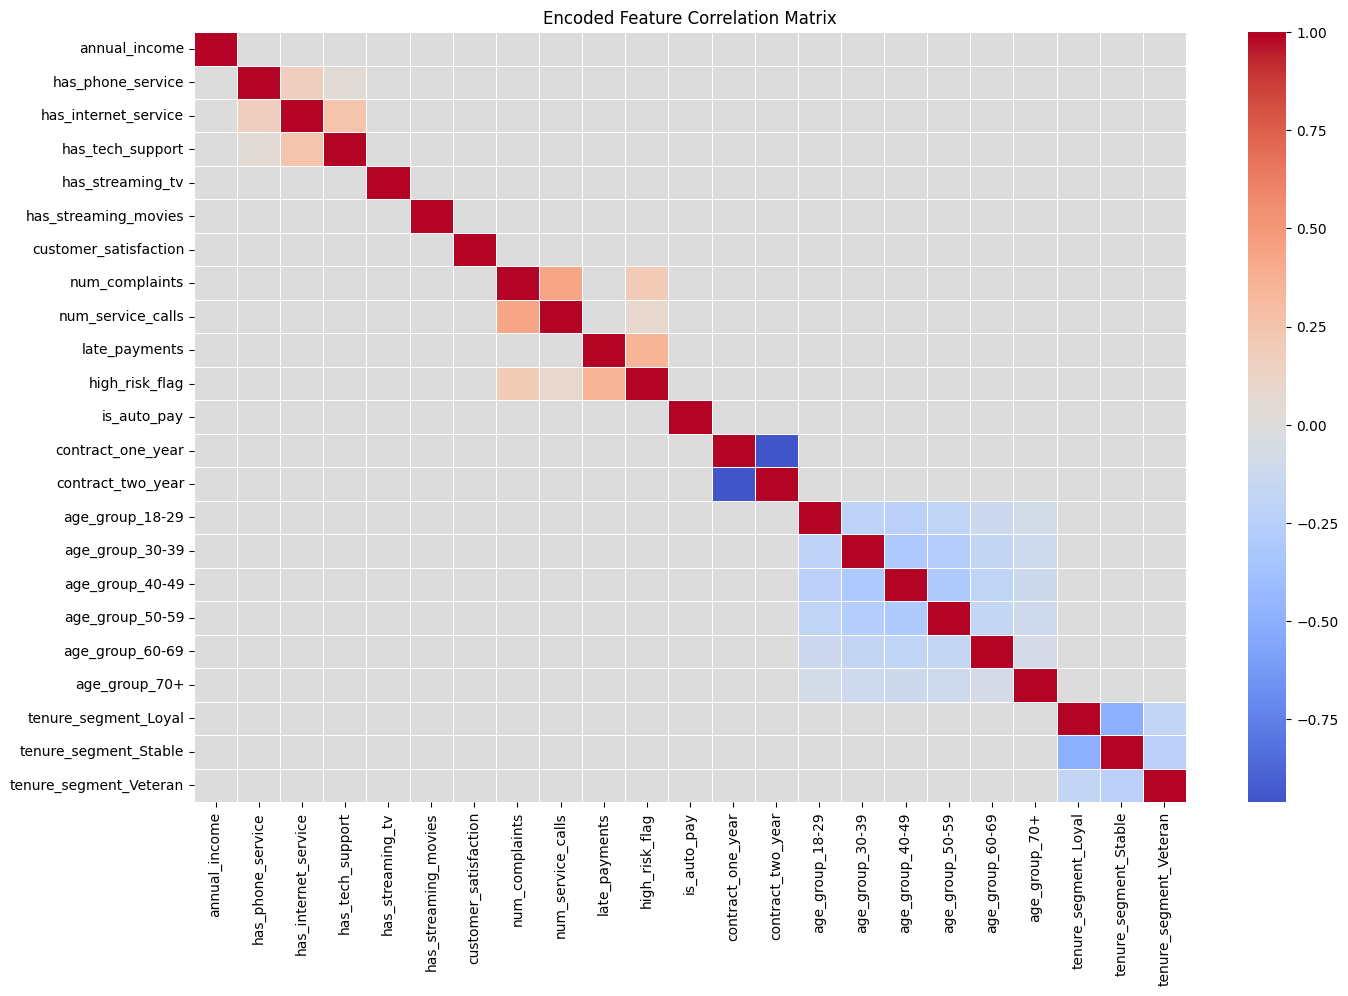

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_encoded.corr()

# Increase figure size because One-Hot Encoding creates many columns
plt.figure(figsize=(16, 10))

# Create the heatmap
sns.heatmap(
    corr_matrix, 
    annot=False,       # Set to True only if you have < 15 columns
    cmap='coolwarm',   # Red = Positive, Blue = Negative
    fmt=".2f", 
    center=0,          # Ensures 0 correlation is a neutral color
    linewidths=0.5
)

plt.title("Encoded Feature Correlation Matrix")
plt.show()